In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Dataset_BUSI_with_GT"

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1066 images belonging to 3 classes.
Found 266 images belonging to 3 classes.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

/tmp/ipykernel_21983/518335959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette="viridis")


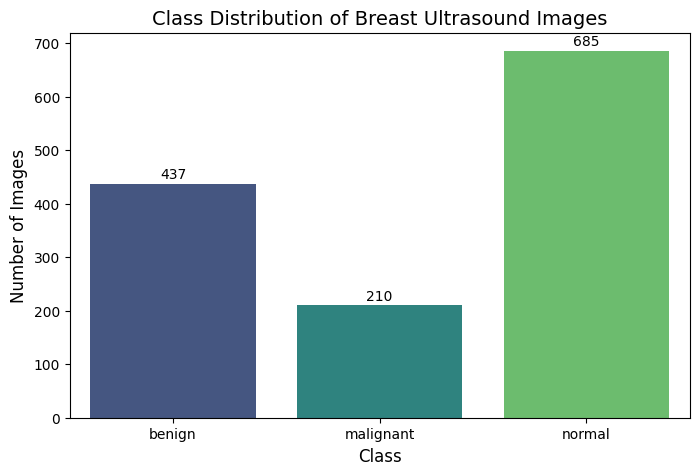

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

classes = ['benign', 'malignant', 'normal']
counts = []

for cls in classes:
    counts.append(len(os.listdir(os.path.join(DATASET_PATH, cls))))

plt.figure(figsize=(8,5))
sns.barplot(x=classes, y=counts, palette="viridis")

plt.title("Class Distribution of Breast Ultrasound Images", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

for i, v in enumerate(counts):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/Dataset_BUSI_with_GT"

classes = os.listdir(DATASET_PATH)

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    for file in os.listdir(path):
        if "mask" in file:
            os.remove(os.path.join(path, file))

print("Mask images removed")

Mask images removed


In [ ]:
for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    for file in os.listdir(path):
        if "mask" in file:
            os.remove(os.path.join(path, file))

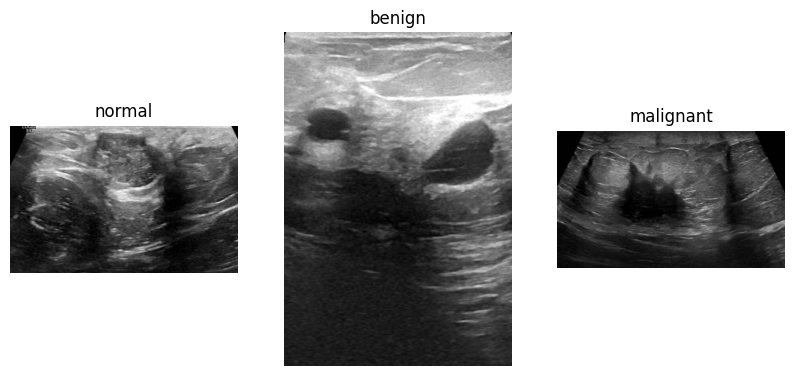

In [ ]:
import cv2

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    path = os.path.join(DATASET_PATH, cls)
    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/Dataset_BUSI_with_GT"

classes = os.listdir(DATASET_PATH)

removed = 0

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    for file in os.listdir(path):
        if "mask" in file:
            os.remove(os.path.join(path, file))
            removed += 1

print(f"Removed {removed} mask images")

Removed 0 mask images


In [ ]:
for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    print(cls, ":", len(os.listdir(path)))

normal : 685
benign : 437
malignant : 210


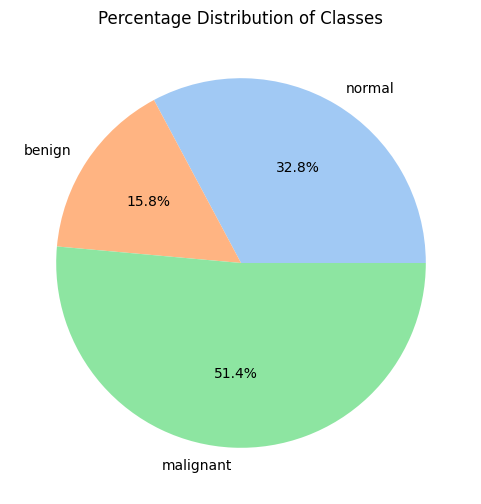

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(counts, labels=classes, autopct='%1.1f%%', colors=sns.color_palette("pastel"))

plt.title("Percentage Distribution of Classes")
plt.show()

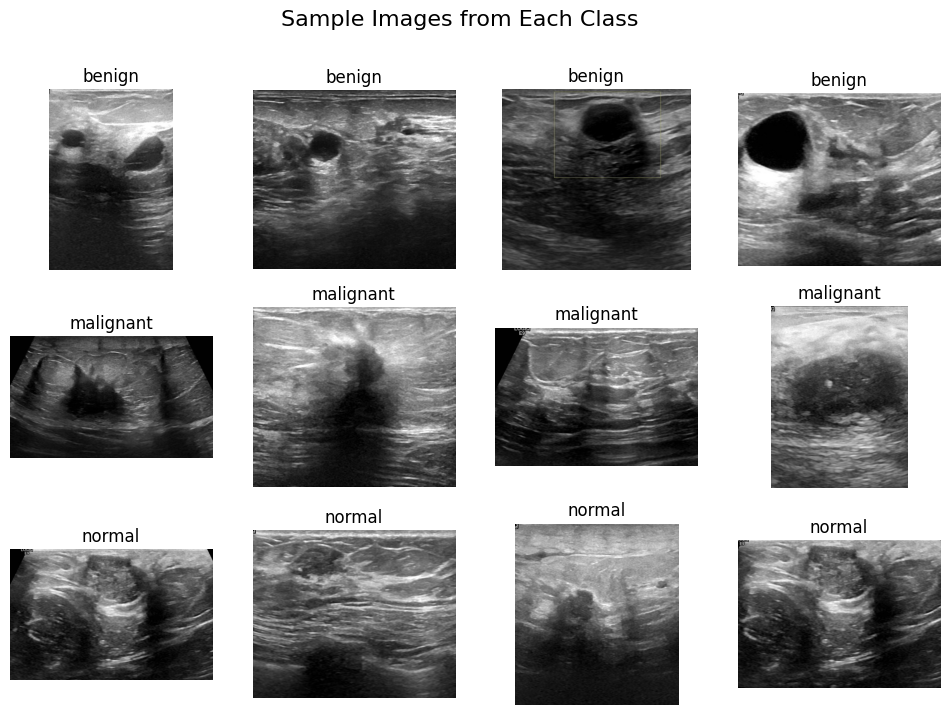

In [ ]:
import cv2
import numpy as np

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(path)[:4]

    for j, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 4, i*4 + j + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=16)
plt.show()

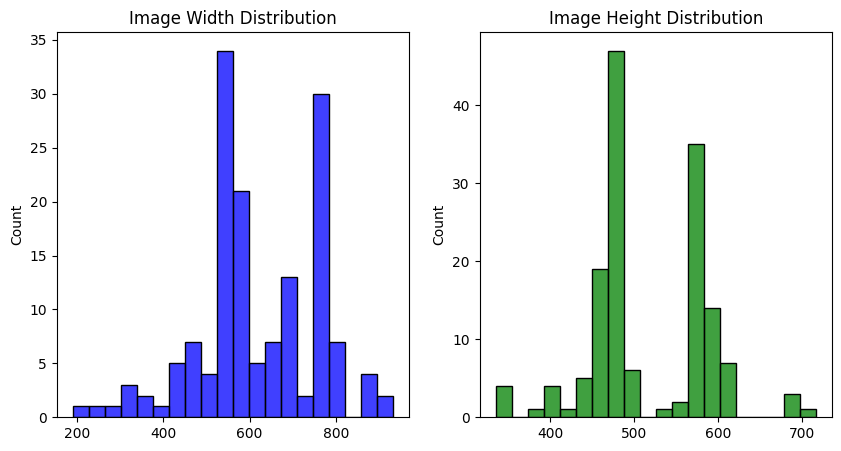

In [ ]:
widths = []
heights = []

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(path)[:50]:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(widths, bins=20, color='blue')
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights, bins=20, color='green')
plt.title("Image Height Distribution")

plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Class": classes,
    "Count": counts
})

print(df)

       Class  Count
0     normal    437
1     benign    210
2  malignant    685


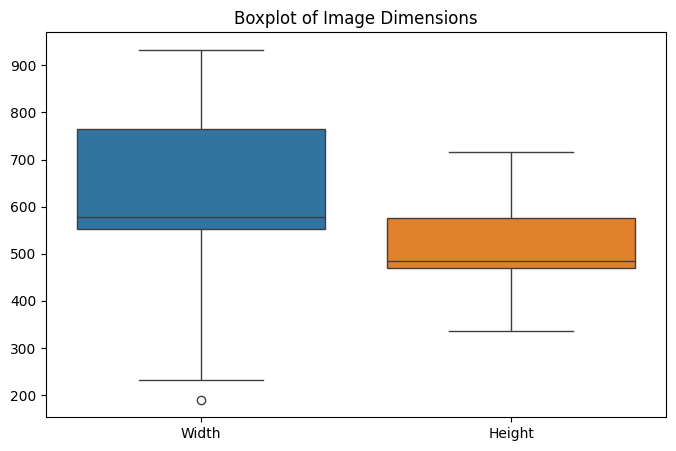

In [ ]:
import pandas as pd

data = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

plt.figure(figsize=(8,5))
sns.boxplot(data=data)

plt.title("Boxplot of Image Dimensions")
plt.show()

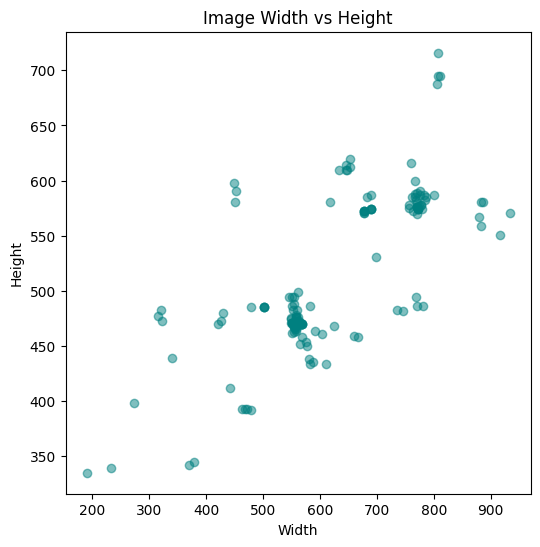

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.5, color='teal')

plt.title("Image Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

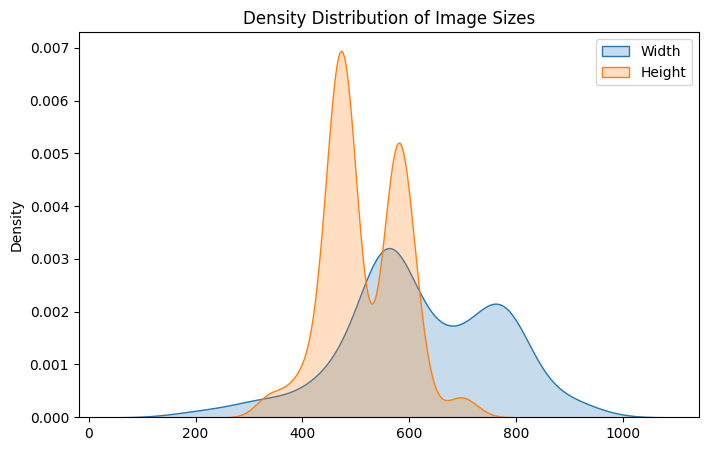

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(widths, label="Width", fill=True)
sns.kdeplot(heights, label="Height", fill=True)

plt.title("Density Distribution of Image Sizes")
plt.legend()
plt.show()

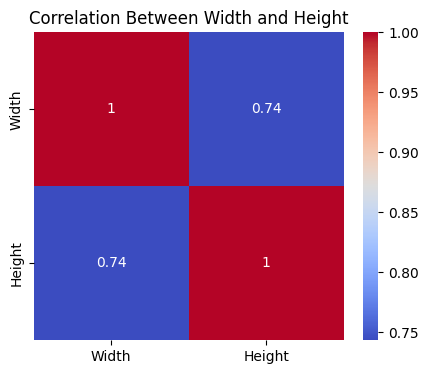

In [ ]:
corr = data.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Width and Height")
plt.show()

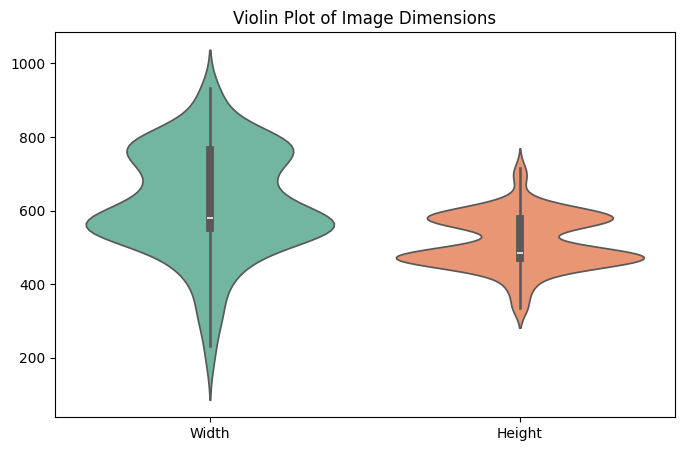

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=data, palette="Set2")

plt.title("Violin Plot of Image Dimensions")
plt.show()

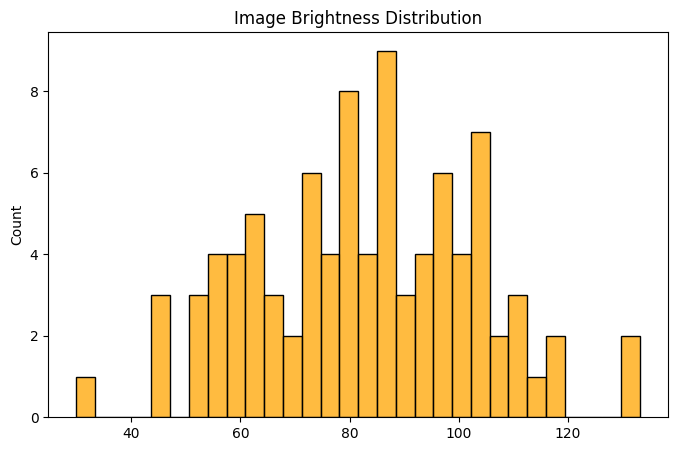

In [ ]:
brightness = []

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(path)[:30]:
        img = cv2.imread(os.path.join(path, img_name))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))

plt.figure(figsize=(8,5))
sns.histplot(brightness, bins=30, color='orange')

plt.title("Image Brightness Distribution")
plt.show()

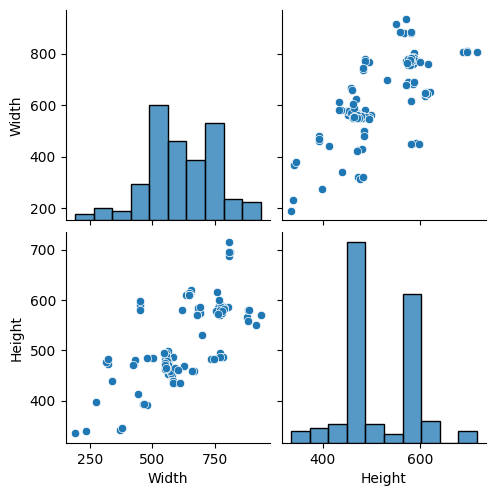

In [ ]:
sns.pairplot(data)
plt.show()

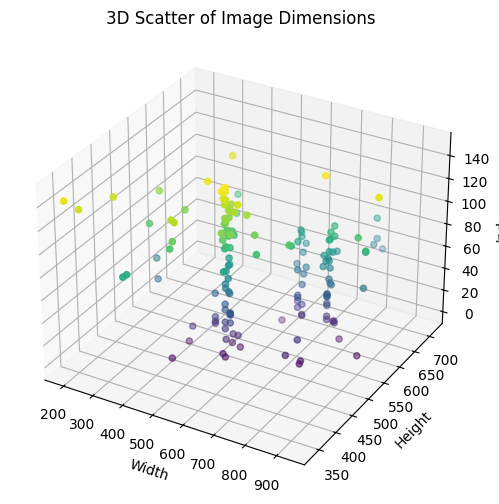

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

z = np.arange(len(widths))

ax.scatter(widths, heights, z, c=z, cmap='viridis')

ax.set_xlabel('Width')
ax.set_ylabel('Height')
ax.set_zlabel('Index')

ax.set_title("3D Scatter of Image Dimensions")

plt.show()

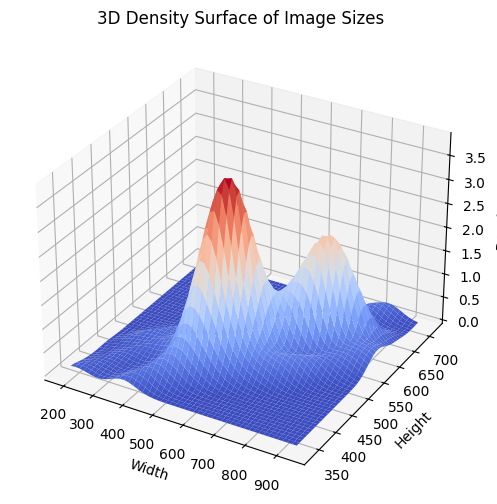

In [ ]:
from scipy.stats import gaussian_kde

data = np.vstack([widths, heights])
kde = gaussian_kde(data)

xgrid = np.linspace(min(widths), max(widths), 50)
ygrid = np.linspace(min(heights), max(heights), 50)

X, Y = np.meshgrid(xgrid, ygrid)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='coolwarm')

ax.set_xlabel('Width')
ax.set_ylabel('Height')
ax.set_zlabel('Density')

ax.set_title("3D Density Surface of Image Sizes")

plt.show()

Binary2

In [ ]:
!pip install opencv-python

In [ ]:
import os
import cv2
import numpy as np

DATASET_PATH = "/content/drive/MyDrive/Dataset_BUSI_with_GT"
IMG_SIZE = (224, 224)

data = []
labels = []

classes = ['benign', 'malignant', 'normal']

for cls in classes:
    path = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(path):

        if "mask" in img_name:
            continue

        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, IMG_SIZE)
        img = img / 255.0

        data.append(img)

        if cls == 'normal':
            labels.append(0)
        else:
            labels.append(1)

X = np.array(data)
y = np.array(labels)

print(" distribution:", np.bincount(y))

 distribution: [685 647]


In [ ]:
from sklearn.utils import resample

X_cancer = X[y == 1]
y_cancer = y[y == 1]

X_normal = X[y == 0]
y_normal = y[y == 0]

X_normal_up, y_normal_up = resample(
    X_normal, y_normal,
    replace=True,
    n_samples=len(X_cancer),
    random_state=42
)

X_bal = np.concatenate([X_cancer, X_normal_up])
y_bal = np.concatenate([y_cancer, y_normal_up])

print("distribution:", np.bincount(y_bal))

distribution: [647 647]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    stratify=y_bal,
    random_state=42
)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9884 - loss: 0.0226 - val_accuracy: 0.9266 - val_loss: 3811.0793
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9894 - loss: 0.0204 - val_accuracy: 0.9189 - val_loss: 4838.0747
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9923 - loss: 0.0182 - val_accuracy: 0.9305 - val_loss: 5257.7212
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9923 - loss: 0.0145 - val_accuracy: 0.9305 - val_loss: 5165.5620
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9932 - loss: 0.0141 - val_accuracy: 0.9382 - val_loss: 5185.9419
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9923 - loss: 0.0176 - val_accuracy: 0.9421 - val_loss: 5290.8975
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9932 - loss: 0.0154 - val_accuracy: 0.9421 - val_loss: 5384.0654
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9894 - loss: 0.0167 - val

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred_classes))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       130
           1       0.96      0.92      0.94       129

    accuracy                           0.94       259
   macro avg       0.94      0.94      0.94       259
weighted avg       0.94      0.94      0.94       259



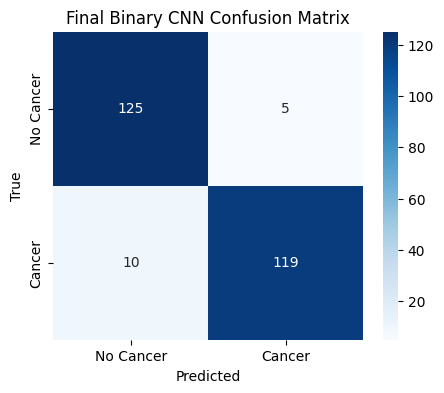

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer','Cancer'],
            yticklabels=['No Cancer','Cancer'])

plt.title("Final Binary CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


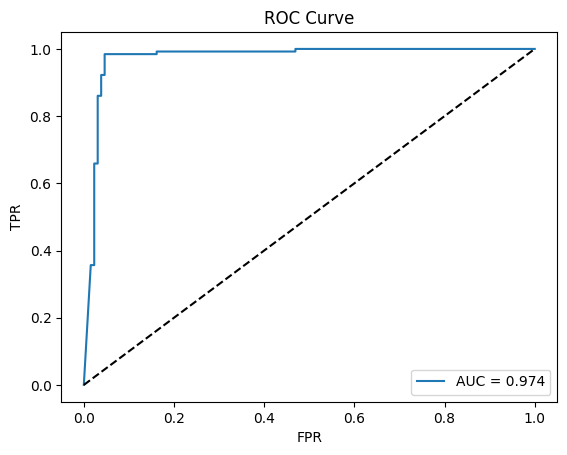

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

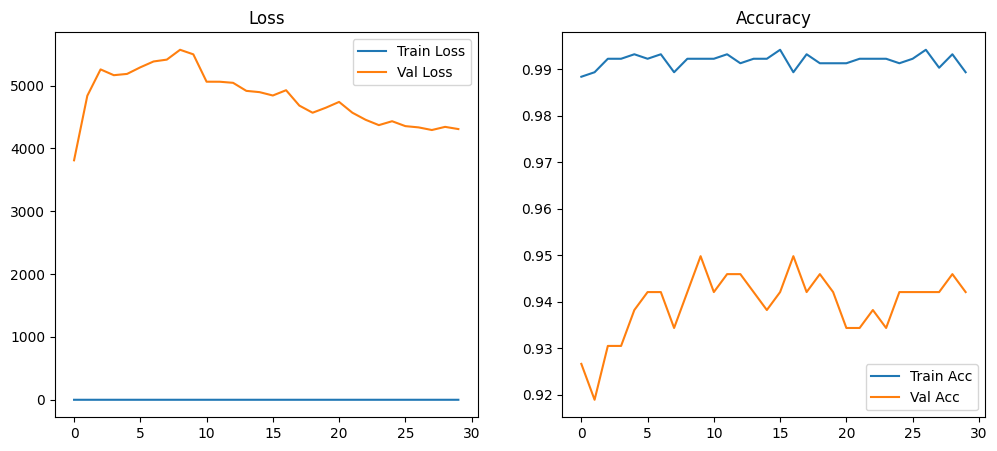

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.show()

ResTNet

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

X_train_resnet = preprocess_input(X_train.copy())
X_test_resnet = preprocess_input(X_test.copy())

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_resnet = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = model_resnet.fit(
    X_train_resnet, y_train,
    validation_data=(X_test_resnet, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.9903 - loss: 0.0198 - val_accuracy: 0.8571 - val_loss: 1.0598
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.9855 - loss: 0.0243 - val_accuracy: 0.9189 - val_loss: 0.4640
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.9884 - loss: 0.0226 - val_accuracy: 0.9498 - val_loss: 0.4064
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.9884 - loss: 0.0248 - val_accuracy: 0.9305 - val_loss: 0.4065
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.9729 - loss: 0.0522 - val_accuracy: 0.8649 - val_loss: 0.7577
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.9807 - loss: 0.0469 - val_accuracy: 0.8494 - val_loss: 0.8195
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.9807 - loss: 0.0454 - val_accuracy: 0.7529 - val_loss: 1.2048
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9894 - loss: 0.0247 - val_accuracy: 0.

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_resnet_fine = model_resnet.fit(
    X_train_resnet, y_train,
    validation_data=(X_test_resnet, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 35s 539ms/step - accuracy: 0.9816 - loss: 0.0352 - val_accuracy: 0.5444 - val_loss: 3.7330
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.9865 - loss: 0.0296 - val_accuracy: 0.9189 - val_loss: 0.6340
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9884 - loss: 0.0283 - val_accuracy: 0.9073 - val_loss: 0.6152
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.9797 - loss: 0.0504 - val_accuracy: 0.8069 - val_loss: 1.0888
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.9836 - loss: 0.0404 - val_accuracy: 0.7954 - val_loss: 1.2780
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.9884 - loss: 0.0242 - val_accuracy: 0.6950 - val_loss: 2.0749
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - accuracy: 0.9874 - loss: 0.0195 - val_accuracy: 0.7645 - val_loss: 1.7926
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - accuracy: 0.9884 - loss: 0.0194 - val_accuracy: 0

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model_resnet.predict(X_test_resnet)
y_pred_classes = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred_classes))

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 543ms/step
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       130
           1       0.96      0.85      0.91       129

    accuracy                           0.91       259
   macro avg       0.92      0.91      0.91       259
weighted avg       0.92      0.91      0.91       259



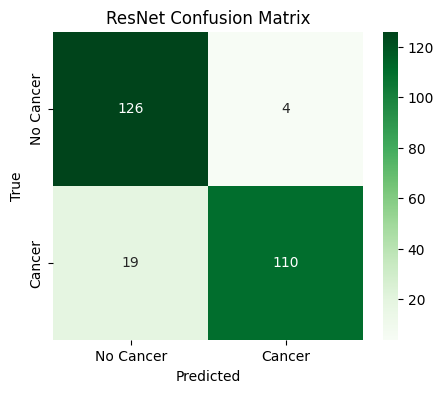

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Cancer','Cancer'],
            yticklabels=['No Cancer','Cancer'])

plt.title("ResNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

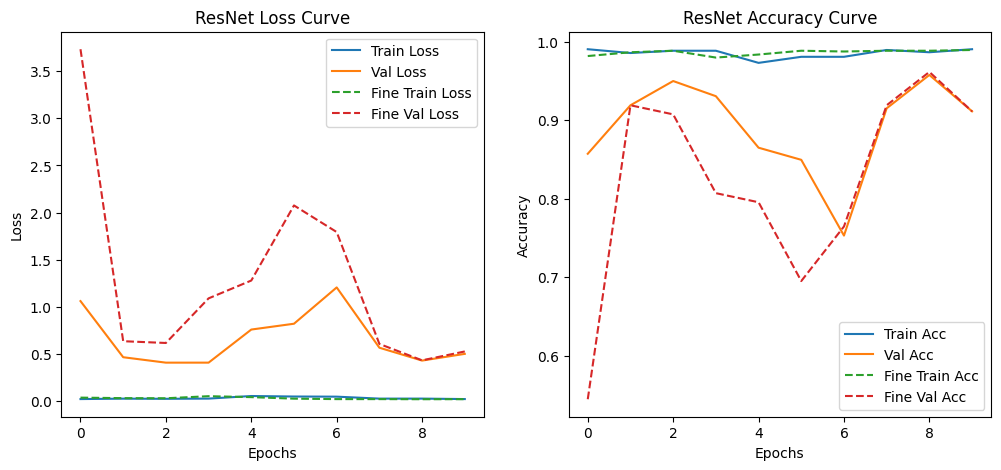

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Val Loss')

if 'history_resnet_fine' in globals():
    plt.plot(history_resnet_fine.history['loss'], linestyle='--', label='Fine Train Loss')
    plt.plot(history_resnet_fine.history['val_loss'], linestyle='--', label='Fine Val Loss')

plt.title("ResNet Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet.history['accuracy'], label='Train Acc')
plt.plot(history_resnet.history['val_accuracy'], label='Val Acc')

if 'history_resnet_fine' in globals():
    plt.plot(history_resnet_fine.history['accuracy'], linestyle='--', label='Fine Train Acc')
    plt.plot(history_resnet_fine.history['val_accuracy'], linestyle='--', label='Fine Val Acc')

plt.title("ResNet Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step


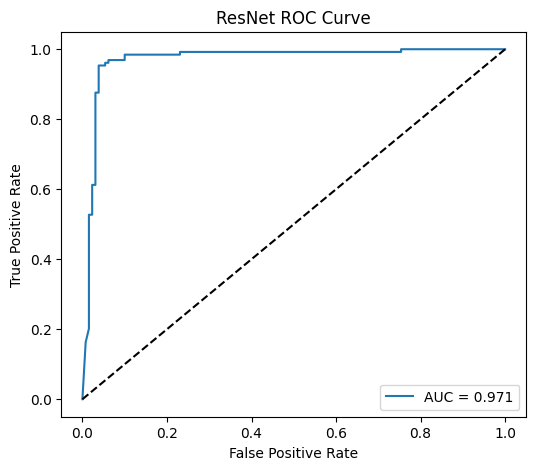

In [ ]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model_resnet.predict(X_test_resnet)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')

plt.title("ResNet ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

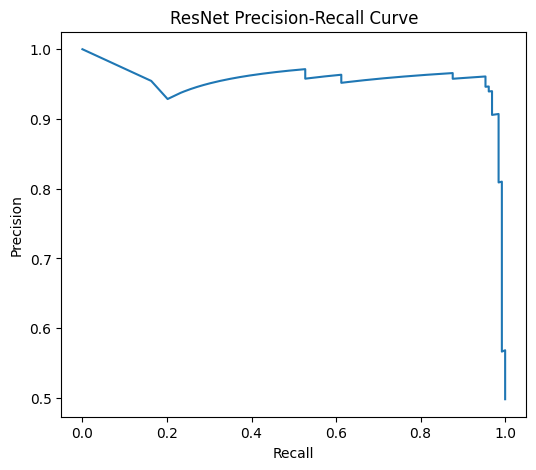

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.title("ResNet Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

Grad-Cam

In [ ]:
model_resnet.trainable = True

In [ ]:
img = X_test[8]

img_uint8 = (img * 255).astype(np.uint8)

img_array = np.expand_dims(img_uint8, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

In [ ]:
pred = model_resnet.predict(img_array)
print("Prediction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Prediction: [[1.]]


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = tf.math.log(predictions[:, pred_index] + 1e-8)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap

In [ ]:
for layer in reversed(model_resnet.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer_name = layer.name
            break
    except:
        continue

print("Last conv layer:", last_conv_layer_name)

Last conv layer: conv5_block3_out


In [ ]:
img = X_test[0]

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model_resnet, last_conv_layer_name)

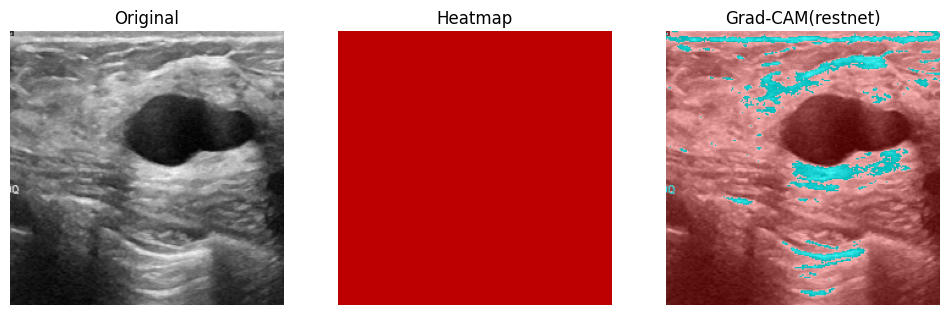

In [ ]:

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img_uint8
superimposed_img = np.uint8(superimposed_img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_uint8)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Grad-CAM(restnet)")
plt.imshow(superimposed_img)
plt.axis('off')

plt.show()
resnet_gradcam_img = superimposed_img

Using Conv Layer: conv2d_11


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_224']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


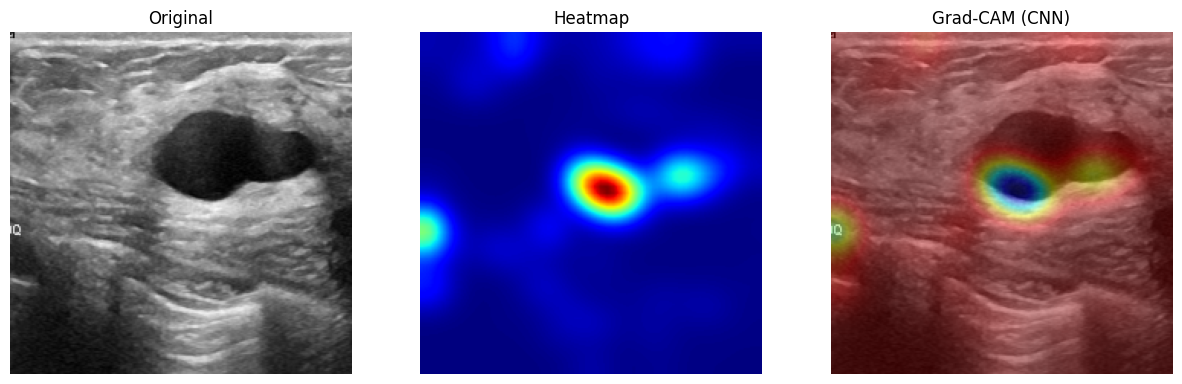

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = X_test[8]
img_uint8 = (img * 255).astype(np.uint8)

img_array = np.expand_dims(img, axis=0)

_ = model(img_array)

last_conv_layer = None
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Using Conv Layer:", last_conv_layer.name)

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.layers[-1].output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
heatmap = heatmap.numpy()

heatmap = cv2.GaussianBlur(heatmap, (15,15), 0)

heatmap = heatmap / (np.max(heatmap) + 1e-8)

heatmap = cv2.resize(heatmap, (224,224))

heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_uint8)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Grad-CAM (CNN)")
plt.imshow(superimposed_img)
plt.axis('off')

plt.show()

Using Conv Layer: conv2d_11


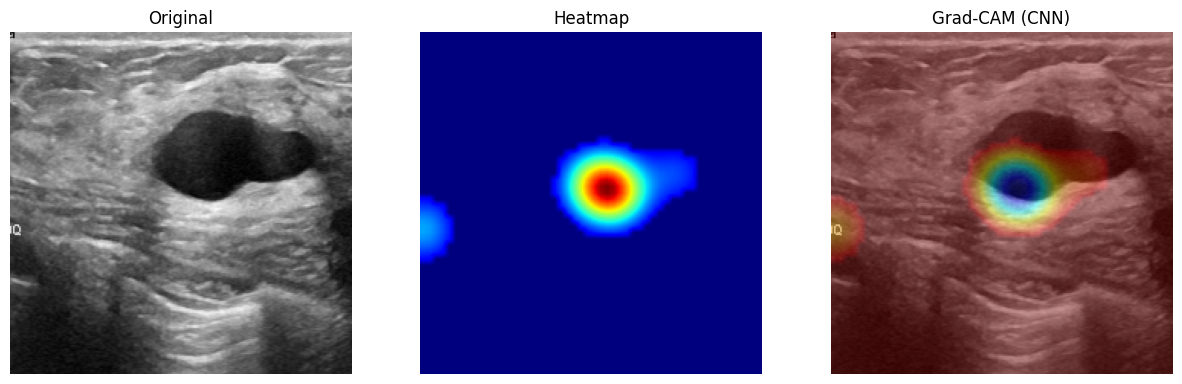

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = X_test[8]
img_uint8 = (img * 255).astype(np.uint8)

img_array = np.expand_dims(img, axis=0)

_ = model(img_array)

last_conv_layer = None
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

print("Using Conv Layer:", last_conv_layer.name)

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.layers[-1].output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
heatmap = heatmap.numpy()

heatmap = heatmap / (np.max(heatmap) + 1e-8)

heatmap = np.where(heatmap > 0.4, heatmap, 0)

heatmap = cv2.GaussianBlur(heatmap, (21,21), 0)

threshold = np.percentile(heatmap, 90)
heatmap = np.where(heatmap >= threshold, heatmap, 0)

heatmap = heatmap / (np.max(heatmap) + 1e-8)

heatmap = cv2.resize(heatmap, (224,224))

heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_uint8)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Grad-CAM (CNN)")
plt.imshow(superimposed_img)
plt.axis('off')

plt.show()

Final Comparision

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

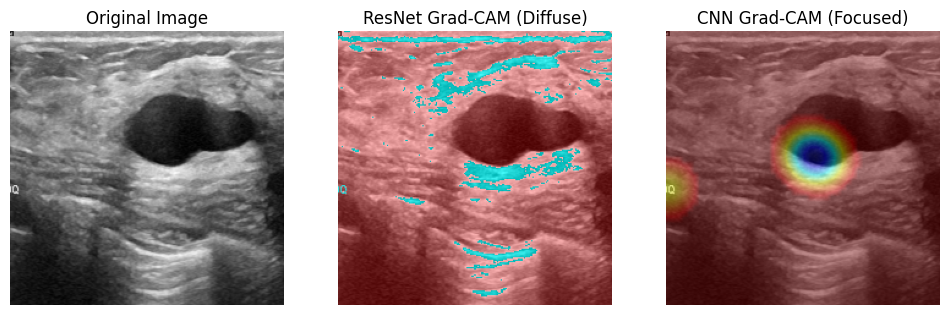

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_uint8)
plt.axis('off')


plt.subplot(1,3,2)
plt.title("ResNet Grad-CAM (Diffuse)")
plt.imshow(resnet_gradcam_img)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("CNN Grad-CAM (Focused)")
plt.imshow(cnn_gradcam_img)
plt.axis('off')



